In [25]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt

from astropy.io import fits
from astropy.table import Table
from astropy.timeseries import LombScargle

import optuna
from scipy.stats import skew, kurtosis
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, accuracy_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [35]:
plt.rcParams.update({
    'axes.titlesize': 14,     # Tamaño del título de cada subgráfico (Periodo)
    'axes.labelsize': 13,     # Tamaño de las etiquetas 'Fase' y 'Mag'
    'xtick.labelsize': 11,    # Tamaño de los números en el eje X
    'ytick.labelsize': 11,    # Tamaño de los números en el eje Y
    'figure.titlesize': 18    # Tamaño del título principal de la figura
})

In [4]:
data = fits.open('ogle-sep-varstars.fits')
Table = Table.read(data, hdu=1)

Id = Table['id']
I = Table['Imag']
V = Table['Vmag']

In [6]:
# 1. Convertir las columnas forzando los errores a NaN
V_num = pd.to_numeric(Table['Vmag'], errors='coerce')
I_num = pd.to_numeric(Table['Imag'], errors='coerce')

#Calcular el índice de color V-I
color = V_num - I_num

In [8]:
Table

id,ra,dec,type,Imag,Vmag,Period,Iamplitude,Period2
,hms,dms,,,,,,
str24,str11,str11,str10,str6,str7,str9,float64,float64
OGLE-VAR-LMC563.16.113,05:48:08.49,-66:31:02.6,OTHER,16.883,16.925,0,0.0,0.0
OGLE-VAR-LMC562.25.45,05:48:20.37,-67:25:26.7,OTHER,15.312,14.677,0,0.0,0.0
OGLE-VAR-LMC562.16.12033,05:48:41.51,-67:31:21.3,OTHER,12.121,13.609,0,0.0,0.0
OGLE-VAR-LMC562.25.266,05:48:51.95,-67:23:39.7,OTHER,17.347,16.702,0,0.0,0.0
OGLE-VAR-LMC562.25.37,05:49:29.85,-67:26:25.3,OTHER,15.440,15.557,0,0.0,0.0
OGLE-VAR-LMC562.16.12092,05:49:33.87,-67:29:02.5,OTHER,13.215,15.122,0,0.0,0.0
OGLE-VAR-LMC562.07.310,05:49:54.99,-67:57:55.1,OTHER,17.925,17.003,0,0.0,0.0
OGLE-VAR-LMC562.32.173,05:50:07.46,-67:05:56.6,OTHER,16.407,16.391,0,0.0,0.0


In [9]:
# Inicializamos las listas vacías
mjds_list = []
mags_list = []

base_dir = 'phot/I/'

# Iteramos sobre los valores de tu columna
for star_id in Id:
    clean_id = str(star_id).strip().replace('OGLE-VAR-', '')
    
    filename = f"{clean_id}.dat"
    filepath = os.path.join(base_dir, filename)
    
    if os.path.exists(filepath):
        # usecols=(0, 1) carga solo mjd y mag, ignorando el error (mag_err)
        mjd, mag = np.loadtxt(filepath, usecols=(0, 1), unpack=True)
        
        mjds_list.append(mjd)
        mags_list.append(mag)
    else:
        print(f"Aviso: Archivo no encontrado -> {filepath}")
        mjds_list.append([])
        mags_list.append([])

In [10]:
np.unique(Table['type'])

ACEP
DCEP
DCEP-1O
DCEP-1O/2O
DCEP-F/1O
DSCT
DSCT-1O/2O
DSCT-F/1O
ECL
ECL-DPV
ECL-OSARG


In [12]:
# Convertir a strings normales y limpiar espacios
var_type = np.array(Table['type']).astype(str)
var_type = np.char.strip(var_type)

# Crear array final
simple_class = np.full(len(var_type), 'OTHER', dtype=object)

# -----------------------------
# Radial pulsators
# -----------------------------
rp_classes = [
    'ACEP',
    'DCEP',
    'DCEP-1O',
    'DCEP-1O/2O',
    'DCEP-F/1O',
    'DSCT',
    'DSCT-1O/2O',
    'DSCT-F/1O',
    'RRLYR',
    'RRLYR-RRd',
    'T2CEP'
]

# -----------------------------
# Eclipsing binaries
# -----------------------------
eb_classes = [
    'ECL',
    'ECL-DPV',
    'ECL-OSARG',
    'ECL-RSCVn',
    'ELL',
    'ELL-ECL',
    'ELL-OSARG'
]

# -----------------------------
# Long period variables
# -----------------------------
lpv_classes = [
    'LPV',
    'LPV-OSARG',
    'LPV-SRV'
]

# Clasificación
simple_class[np.isin(var_type, rp_classes)] = 'RP'
simple_class[np.isin(var_type, eb_classes)] = 'EB'
simple_class[np.isin(var_type, lpv_classes)] = 'LPV'

In [13]:
np.unique(simple_class)

array(['EB', 'LPV', 'OTHER', 'RP'], dtype=object)

### Clase OTHER

Índices seleccionados aleatoriamente: [2587 2171 1559  702 1041  947 1798 1009 2229 1991]


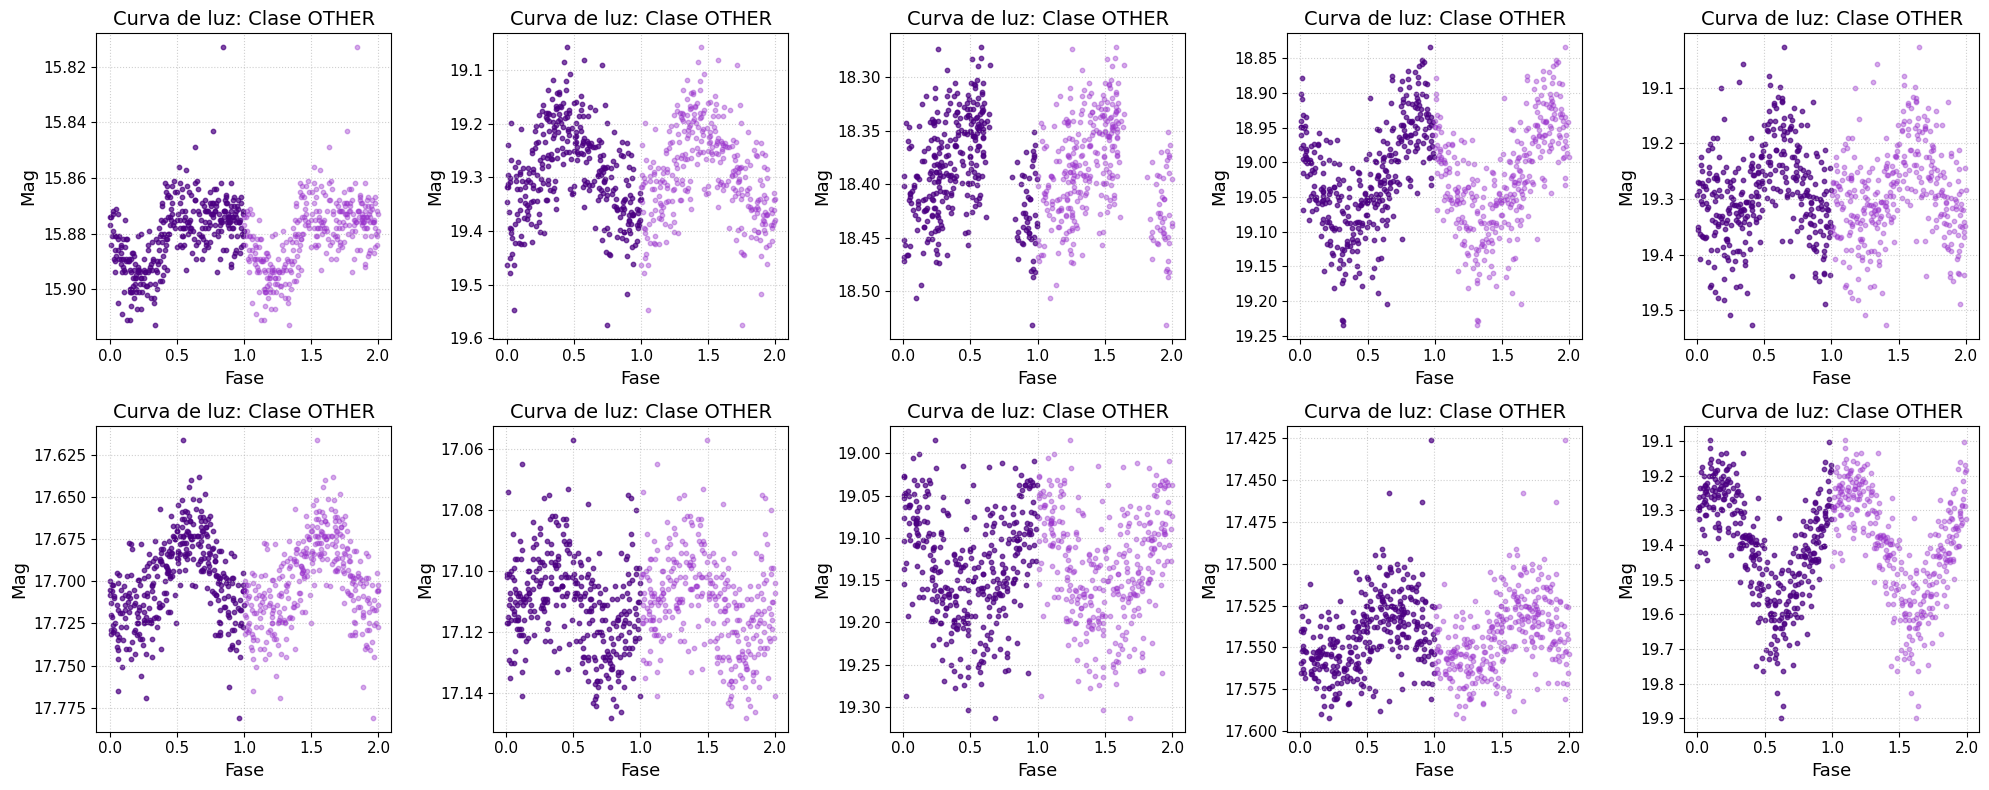

In [36]:
# --- Paso 1: Encontrar los índices de la clase 'OTHER' ---
# Convertimos simple_class a un array de numpy (si no lo es ya) para buscar eficientemente
simple_class_arr = np.array(simple_class)

# BUSCA AQUÍ: Cambia 'OTHER' si en tu variable estaba bien escrito, o déjalo si tiene el typo
indices_other = np.where(simple_class_arr == 'OTHER')[0]

# --- Paso 2: Seleccionar 10 índices aleatorios ---
# Usamos un generador de números aleatorios para reproducibilidad si lo deseas
rng = np.random.default_rng() 
indices_seleccionados = rng.choice(indices_other, size=10, replace=False)

print(f"Índices seleccionados aleatoriamente: {indices_seleccionados}")

# --- Paso 3: Iterar, calcular Lomb-Scargle y graficar ---
# Configurar la grilla de gráficos (2 filas x 5 columnas para las 10 estrellas)
fig, axes = plt.subplots(2, 5, figsize=(20, 8), sharey=False)
axes = axes.flatten()

for i, idx in enumerate(indices_seleccionados):
    # Extraer los datos de las listas usando el índice
    t = np.array(mjds_list[idx])
    y = np.array(mags_list[idx])
    
    # Limpieza rápida por si tienes NaNs en las listas (muy común en curvas de luz)
    mask = ~np.isnan(t) & ~np.isnan(y)
    t, y = t[mask], y[mask]
    
    # Estimar errores si no tienes (Lomb-Scargle los agradece, si no, se asumen uniformes)
    dy = 0.01 
    
    # Calcular el periodograma de Lomb-Scargle
    # Definimos un rango de frecuencias razonable (ej. períodos entre 0.05 días y 100 días)
    frequency, power = LombScargle(t, y, dy).autopower(minimum_frequency=1/100, maximum_frequency=1/0.05)
    
    # Encontrar la frecuencia con la máxima potencia (el período más probable)
    best_frequency = frequency[np.argmax(power)]
    best_period = 1 / best_frequency
    
    # Calcular la fase para plegar la curva de luz: (tiempo / periodo) % 1
    phase = (t / best_period) % 1
    
    # --- Paso 4: Graficar la curva de luz en fase ---
    ax = axes[i]
    
    # Graficamos dos ciclos (fase de 0 a 2) para ver mejor la continuidad de la variabilidad
    ax.scatter(phase, y, color='indigo', s=10, alpha=0.7, label='Ciclo 1')
    ax.scatter(phase + 1, y, color='darkorchid', s=10, alpha=0.4, label='Ciclo 2')
    
    ax.set_title('Curva de luz: Clase OTHER') # Como es astronomía, invertimos el eje Y 
    ax.invert_yaxis()
    ax.set_xlabel('Fase')
    ax.set_ylabel('Mag')
    ax.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

### RANDOM FOREST

In [20]:
# ============================================================================
# 1. CLASES Y FUNCIONES MATEMÁTICAS (CÁLCULO DE FEATURES)
# ============================================================================

class ParametrosEstrella:
    def __init__(self, t, magnitudes, periodo):
        self.t = t
        self.magnitudes = magnitudes
        self.periodo = periodo
        self.t0 = t[np.argmin(magnitudes)] # Usamos el mínimo como t0 referencial
        
        self.fases = ((self.t - self.t0) % self.periodo) / self.periodo
        self.sorted_idx = np.argsort(self.fases)
        self.fases_sorted = self.fases[self.sorted_idx]
        self.mags_sorted = magnitudes[self.sorted_idx]
        
        self.mag_median = np.median(magnitudes)
        self.mag_std = np.std(magnitudes)
        self.mag_mean = np.mean(magnitudes)

def calcular_amplitud_robusta(magnitudes, q_low=0.05, q_high=0.95):
    return np.percentile(magnitudes, q_high * 100) - np.percentile(magnitudes, q_low * 100)

def calcular_factor_simetria(params, q_low=0.02, q_high=0.98):
    magnitudes, fases = params.magnitudes, params.fases
    mag_min_brillo = np.percentile(magnitudes, q_high * 100) 
    mag_max_brillo = np.percentile(magnitudes, q_low * 100)  
    
    idx_min_brillo = np.argmin(np.abs(magnitudes - mag_min_brillo))
    idx_max_brillo = np.argmin(np.abs(magnitudes - mag_max_brillo))
    
    fase_min_brillo = fases[idx_min_brillo]
    fase_max_brillo = fases[idx_max_brillo]
    
    if fase_min_brillo < fase_max_brillo:
        return fase_max_brillo - fase_min_brillo
    return 1.0 + fase_max_brillo - fase_min_brillo

def calcular_ancho_minimos(params):
    umbral_minimo = np.percentile(params.mags_sorted, 75) 
    en_minimo = params.mags_sorted > umbral_minimo
    return np.sum(en_minimo) / len(params.mags_sorted)

def detectar_minimos_eclipses_mejorado(params):
    fases_sorted, mags_sorted = params.fases_sorted, params.mags_sorted
    mitad_1, mitad_2 = fases_sorted < 0.5, fases_sorted >= 0.5
    
    mags_mitad1, mags_mitad2 = mags_sorted[mitad_1], mags_sorted[mitad_2]
    fases_mitad1, fases_mitad2 = fases_sorted[mitad_1], fases_sorted[mitad_2]
    
    if len(mags_mitad1) < 5 or len(mags_mitad2) < 5:
        return False, np.nan
    
    val_min1 = np.percentile(mags_mitad1, 95)
    idx_min1 = np.argmin(np.abs(mags_mitad1 - val_min1))
    val_min2 = np.percentile(mags_mitad2, 95)
    idx_min2 = np.argmin(np.abs(mags_mitad2 - val_min2))
    
    prof1 = mags_mitad1[idx_min1] - params.mag_median
    prof2 = mags_mitad2[idx_min2] - params.mag_median
    
    umbral = 1.5 * params.mag_std
    if prof1 < umbral or prof2 < umbral:
        return False, np.nan
        
    distancia = abs(fases_mitad2[idx_min2] - fases_mitad1[idx_min1])
    if not (0.35 < distancia < 0.65):
        return False, np.nan
        
    if calcular_ancho_minimos(params) > 0.5:
        return False, np.nan
        
    prof_primario, prof_secundario = max(prof1, prof2), min(prof1, prof2)
    ratio = prof_secundario / prof_primario if prof_primario > 0 else np.nan
    
    return True, ratio

def calcular_fourier_params(params):
    t, magnitudes = params.t, params.magnitudes
    mag_norm = (magnitudes - params.mag_mean) / params.mag_std
    omega = 2 * np.pi / params.periodo
    
    try:
        A1_cos = np.sum(mag_norm * np.cos(omega * (t - params.t0))) * 2 / len(t)
        A1_sin = np.sum(mag_norm * np.sin(omega * (t - params.t0))) * 2 / len(t)
        A1 = np.sqrt(A1_cos**2 + A1_sin**2)
        phi1 = np.arctan2(A1_sin, A1_cos)
        
        A2_cos = np.sum(mag_norm * np.cos(2 * omega * (t - params.t0))) * 2 / len(t)
        A2_sin = np.sum(mag_norm * np.sin(2 * omega * (t - params.t0))) * 2 / len(t)
        A2 = np.sqrt(A2_cos**2 + A2_sin**2)
        phi2 = np.arctan2(A2_sin, A2_cos)
        
        R21 = A2 / A1 if A1 > 0 else np.nan
        phi21 = (phi2 - 2 * phi1) % (2 * np.pi)
        return R21, phi21
    except:
        return np.nan, np.nan

def calcular_indice_planitud(fases, magnitudes, fase_min, amplitud_total):
    ventana = 0.06
    if fase_min < ventana:
        mask = (fases > (1 - (ventana - fase_min))) | (fases < (fase_min + ventana))
    elif fase_min > (1 - ventana):
        mask = (fases > (fase_min - ventana)) | (fases < (ventana - (1 - fase_min)))
    else:
        mask = (fases > fase_min - ventana) & (fases < fase_min + ventana)
    
    mags_fondo = magnitudes[mask]
    if len(mags_fondo) < 4: 
        return np.nan
        
    return (np.std(mags_fondo) * 2) / amplitud_total if amplitud_total > 0 else np.nan

# ============================================================================
# 2. EXTRACCIÓN DE FEATURES POR ESTRELLA
# ============================================================================

def extraer_features(t, magnitudes):
    """Calcula todas las características para una sola curva de luz."""
    if len(t) < 15:
        return [np.nan] * 9

    try:
        ls = LombScargle(t, magnitudes)
        freq, power = ls.autopower(minimum_frequency=1/100, maximum_frequency=10)
        periodo_ls = 1.0 / freq[np.argmax(power)]
    except:
        return [np.nan] * 9

    # Features generales al periodo base
    amplitud = calcular_amplitud_robusta(magnitudes)
    sk = skew(magnitudes)
    kurt = kurtosis(magnitudes, fisher=True)
    
    params_p = ParametrosEstrella(t, magnitudes, periodo_ls)
    simetria = calcular_factor_simetria(params_p)
    R21, phi21 = calcular_fourier_params(params_p)

    # Test de binarias al periodo doble
    periodo_2p = 2 * periodo_ls
    params_2p = ParametrosEstrella(t, magnitudes, periodo_2p)
    es_binaria, ratio_prof = detectar_minimos_eclipses_mejorado(params_2p)

    if es_binaria:
        p_final = periodo_2p
        idx_min = np.argmax(magnitudes)
        planitud = calcular_indice_planitud(params_2p.fases, magnitudes, params_2p.fases[idx_min], amplitud)
    else:
        p_final = periodo_ls
        planitud = np.nan
        ratio_prof = np.nan

    return [p_final, amplitud, simetria, R21, phi21, sk, kurt, planitud, ratio_prof]

In [22]:
# ============================================================================
# 3. CONSTRUCCIÓN DEL DATASET Y PREPROCESAMIENTO (ACTUALIZADO)
# ============================================================================

print("Extrayendo features de las curvas de luz...")
features_list = []

# Asumimos que mjds_list y mags_list ya existen en tu entorno de memoria
for mjd, mag in zip(mjds_list, mags_list):
    if len(mjd) > 0:
        features_list.append(extraer_features(mjd, mag))
    else:
        features_list.append([np.nan] * 9)

# Crear DataFrame base con los nombres originales de las columnas
nombres_cols = ['periodo', 'amplitud', 'simetria', 'R21', 'phi21', 'skewness', 'kurtosis', 'planitud', 'ratio_prof']
X = pd.DataFrame(features_list, columns=nombres_cols)

# --- PASO 1: Añadir la variable color calculada previamente ---
# Se agrega a X y actualizamos la lista de nombres de columnas
X['V-I'] = color
nombres_cols.append('V-I')

# Preparar etiquetas reales desde la tabla original
y = np.array(simple_class)  # Lo convertimos a array de numpy para facilitar filtros lógicos

# --- PASO 2: Filtrar NaNs Y excluir la clase 'OTHER' ---
# La máscara ahora requiere: que el periodo NO sea NaN Y que la clase NO sea 'OTHER'
mascara_validos = (~X['periodo'].isna()) & (y != 'OTHER')

# Aplicar el filtro a X e y de manera simultánea
X_valid = X[mascara_validos].copy()
y_valid = y[mascara_validos]

# --- PASO 3: Imputación y Partición de datos ---
# El imputer ahora también procesará la columna V-I si llega a tener algún NaN aislado
imputer = SimpleImputer(strategy='median')
X_imputed = pd.DataFrame(imputer.fit_transform(X_valid), columns=nombres_cols)

# Partición 60% Train / 40% Test estratificada
X_train, X_test, y_train, y_test = train_test_split(
    X_imputed, 
    y_valid, 
    test_size=0.40, 
    random_state=42, 
    stratify=y_valid
)

print(f"Dataset listo. Tamaño final de entrenamiento: {X_train.shape[0]} estrellas.")
print(f"Clases incluidas en el entrenamiento: {np.unique(y_train)}")

Extrayendo features de las curvas de luz...
Dataset listo. Tamaño final de entrenamiento: 3189 estrellas.
Clases incluidas en el entrenamiento: ['EB' 'LPV' 'RP']


In [27]:
# Imprimir el conteo de estrellas en cada conjunto
print("==================================================")
print("             RESUMEN DEL DATASET                  ")
print("==================================================")
print(f"Estrellas para entrenamiento (60%): {X_train.shape[0]}")
print(f"Estrellas para validación/test (40%): {X_test.shape[0]}")
print(f"Total de estrellas procesadas:       {X_train.shape[0] + X_test.shape[0]}")
print("==================================================")

# Opcional: Mostrar cuántas estrellas quedaron por cada clase en el entrenamiento
print("\nDistribución de clases en el conjunto de entrenamiento:")
print(y_train.value_counts() if hasattr(y_train, 'value_counts') else pd.Series(y_train).value_counts())

             RESUMEN DEL DATASET                  
Estrellas para entrenamiento (60%): 3189
Estrellas para validación/test (40%): 2127
Total de estrellas procesadas:       5316

Distribución de clases en el conjunto de entrenamiento:
LPV    1679
EB      919
RP      591
Name: count, dtype: int64


In [23]:
# ============================================================================
# 4. OPTIMIZACIÓN CON OPTUNA Y RANDOM FOREST
# ============================================================================

print("Iniciando optimización de hiperparámetros con Optuna...")

def objective(trial):
    # Espacio de búsqueda para los hiperparámetros
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 300),
        'max_depth': trial.suggest_int('max_depth', 5, 30),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 15),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
        'random_state': 42,
        'n_jobs': -1
    }
    
    rf = RandomForestClassifier(**params)
    
    # Usamos cross-validation de 3 pliegues dentro del set de entrenamiento
    score = cross_val_score(rf, X_train, y_train, cv=3, scoring='accuracy').mean()
    return score

# Configurar el estudio de Optuna
optuna.logging.set_verbosity(optuna.logging.WARNING) # Para no saturar la consola
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=30) # Aumentar n_trials si se desea mayor búsqueda

print(f"Mejores hiperparámetros encontrados: {study.best_params}")

# ============================================================================
# 5. ENTRENAMIENTO FINAL Y EVALUACIÓN
# ============================================================================

print("Entrenando modelo final y evaluando en el 40% de test...")
mejor_rf = RandomForestClassifier(**study.best_params, random_state=42, n_jobs=-1)
mejor_rf.fit(X_train, y_train)

# Predicciones
y_pred = mejor_rf.predict(X_test)

# Reporte de resultados
print("\n" + "="*60)
print("REPORTE DE CLASIFICACIÓN (SET DE TEST 40%)")
print("="*60)
print(classification_report(y_test, y_pred))

# Importancia de las variables
importancias = pd.DataFrame({
    'Feature': nombres_cols,
    'Importancia': mejor_rf.feature_importances_
}).sort_values('Importancia', ascending=False)

print("\nImportancia de las características:")
print(importancias.to_string(index=False))

Iniciando optimización de hiperparámetros con Optuna...
Mejores hiperparámetros encontrados: {'n_estimators': 256, 'max_depth': 24, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 'log2'}
Entrenando modelo final y evaluando en el 40% de test...

REPORTE DE CLASIFICACIÓN (SET DE TEST 40%)
              precision    recall  f1-score   support

          EB       0.97      0.95      0.96       613
         LPV       0.98      0.99      0.99      1120
          RP       0.98      0.96      0.97       394

    accuracy                           0.98      2127
   macro avg       0.98      0.97      0.97      2127
weighted avg       0.98      0.98      0.98      2127


Importancia de las características:
   Feature  Importancia
       V-I     0.377033
  amplitud     0.203227
  skewness     0.126937
  kurtosis     0.110430
   periodo     0.066932
     phi21     0.058026
       R21     0.026019
  simetria     0.018885
  planitud     0.007205
ratio_prof     0.005307


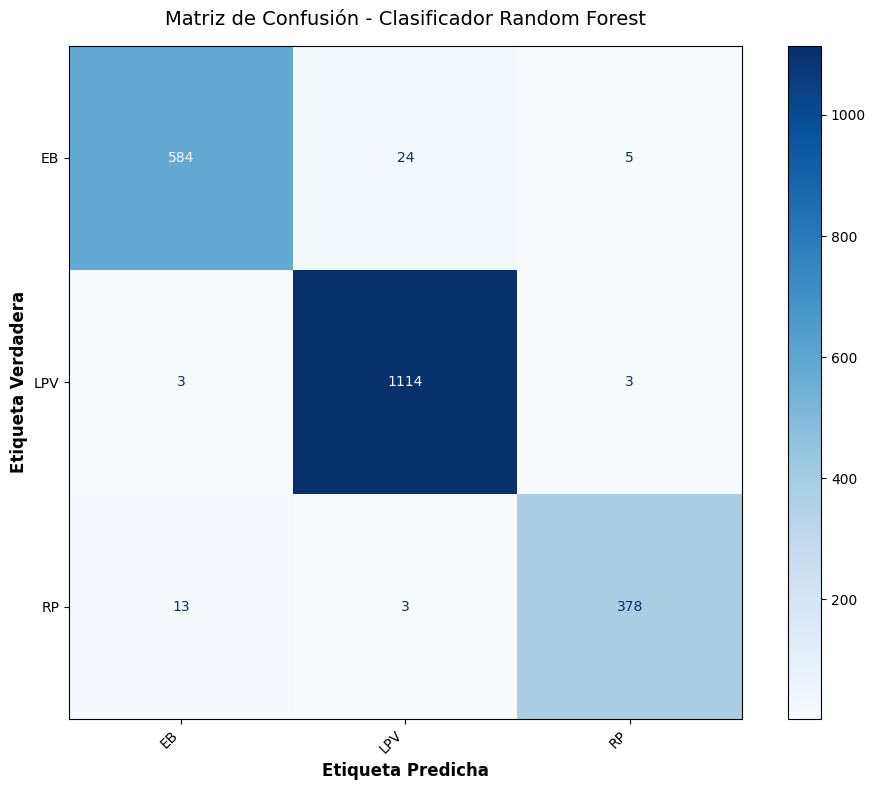

In [24]:
# Calcular la matriz de confusión asegurando el orden correcto de las etiquetas
cm = confusion_matrix(y_test, y_pred, labels=mejor_rf.classes_)

# Configurar el tamaño de la figura para que no se vea amontonada
fig, ax = plt.subplots(figsize=(10, 8))

# Crear el objeto de visualización
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=mejor_rf.classes_)

# Renderizar el gráfico
# cmap='Blues' da un tono académico y limpio. 
# values_format='d' fuerza a que los números sean enteros (sin notación científica)
disp.plot(cmap='Blues', ax=ax, values_format='d', colorbar=True)

# Ajustes estéticos
plt.title('Matriz de Confusión - Clasificador Random Forest', fontsize=14, pad=15)
plt.xlabel('Etiqueta Predicha', fontsize=12, fontweight='bold')
plt.ylabel('Etiqueta Verdadera', fontsize=12, fontweight='bold')

# Rotar las etiquetas del eje X a 45 grados por si hay nombres de clases largos
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)

# Evitar que los márgenes corten las etiquetas
plt.tight_layout()

# Mostrar en pantalla
plt.show()

# Opcional: Si quieres guardarla directamente en alta calidad para tu documento:
# plt.savefig('matriz_confusion_rf.png', dpi=300, bbox_inches='tight')

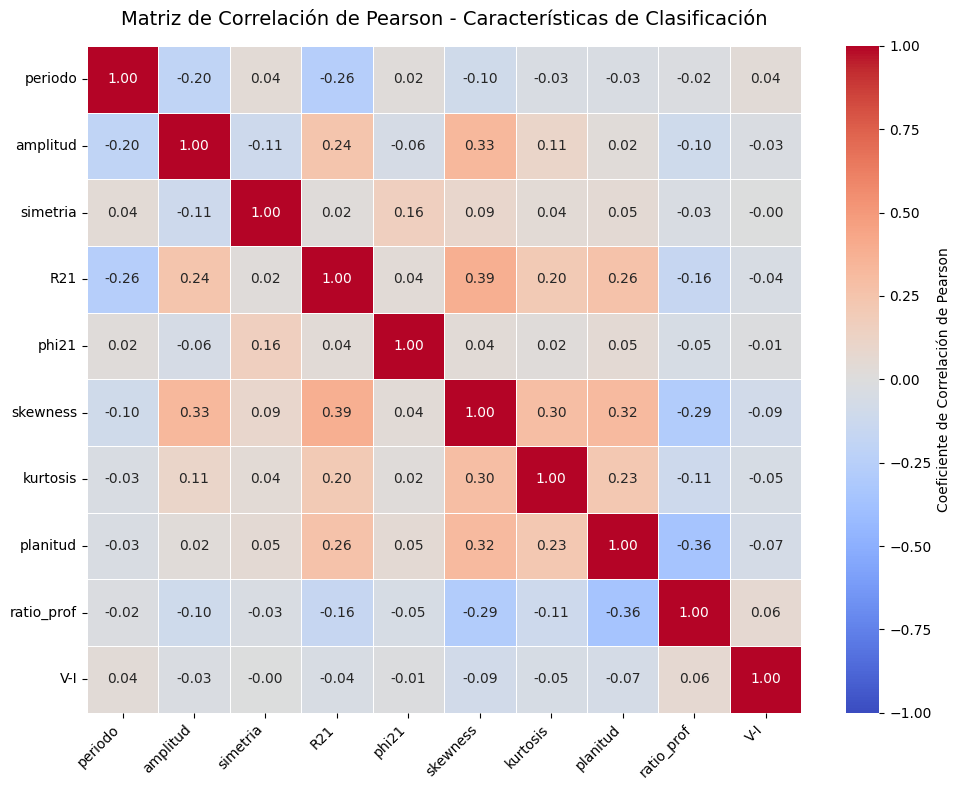

In [26]:
# 1. Calcular la matriz de correlación de Pearson
# El método .corr() de Pandas calcula Pearson por defecto
corr_matrix = X_imputed.corr(method='pearson')

# 2. Configurar el lienzo de Matplotlib
plt.figure(figsize=(10, 8))

# 3. Dibujar el mapa de calor (Heatmap)
# Usamos una paleta divergente 'coolwarm' (ideal para ver correlaciones + y -)
sns.heatmap(
    corr_matrix, 
    annot=True,          # Muestra los valores numéricos dentro de cada celda
    fmt=".2f",           # Limita a 2 decimales
    cmap='coolwarm',     # Color azul para negativas, rojo para positivas
    vmin=-1, vmax=1,     # Escala estricta de la correlación de Pearson
    linewidths=0.5,      # Línea sutil de separación entre celdas
    cbar_kws={"label": "Coeficiente de Correlación de Pearson"}
)

# 4. Ajustes estéticos y etiquetas
plt.title('Matriz de Correlación de Pearson - Características de Clasificación', fontsize=14, pad=15)
plt.xticks(rotation=45, ha='right')  # Rotar nombres de columnas para que no se solapen
plt.yticks(rotation=0)
plt.tight_layout()

# 5. Mostrar el gráfico
plt.show()

### Ejemplos visuales de curvas de luz de las clases

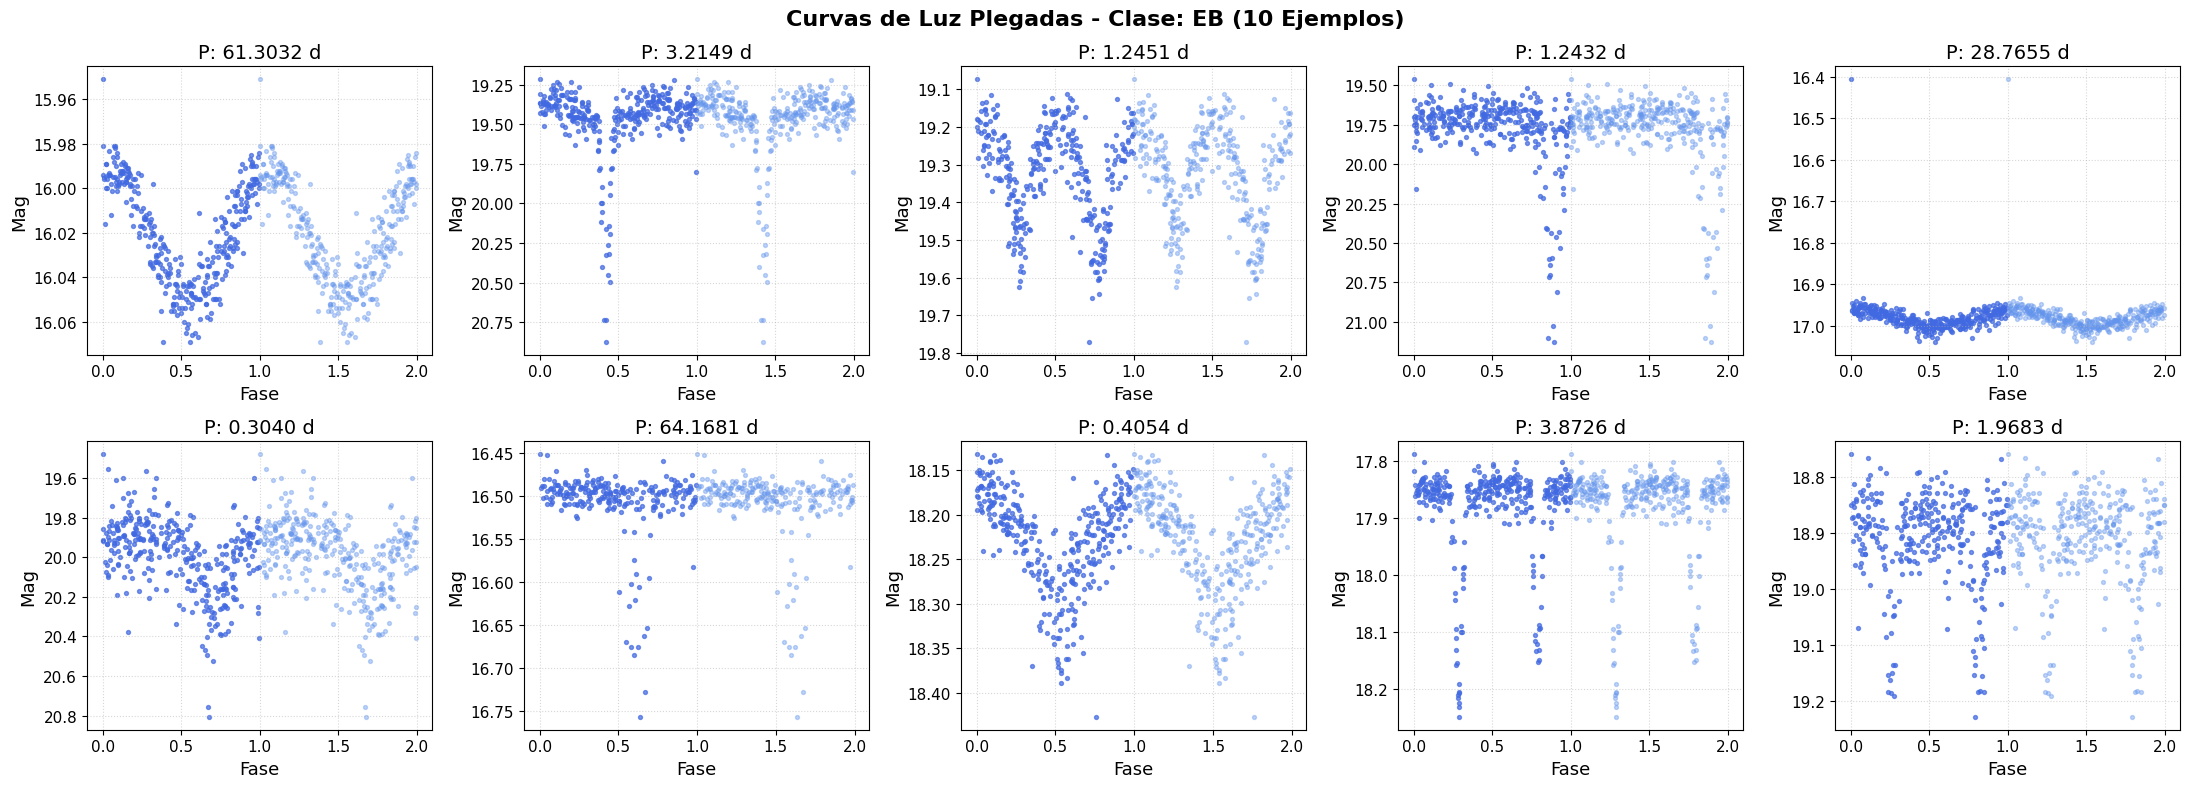

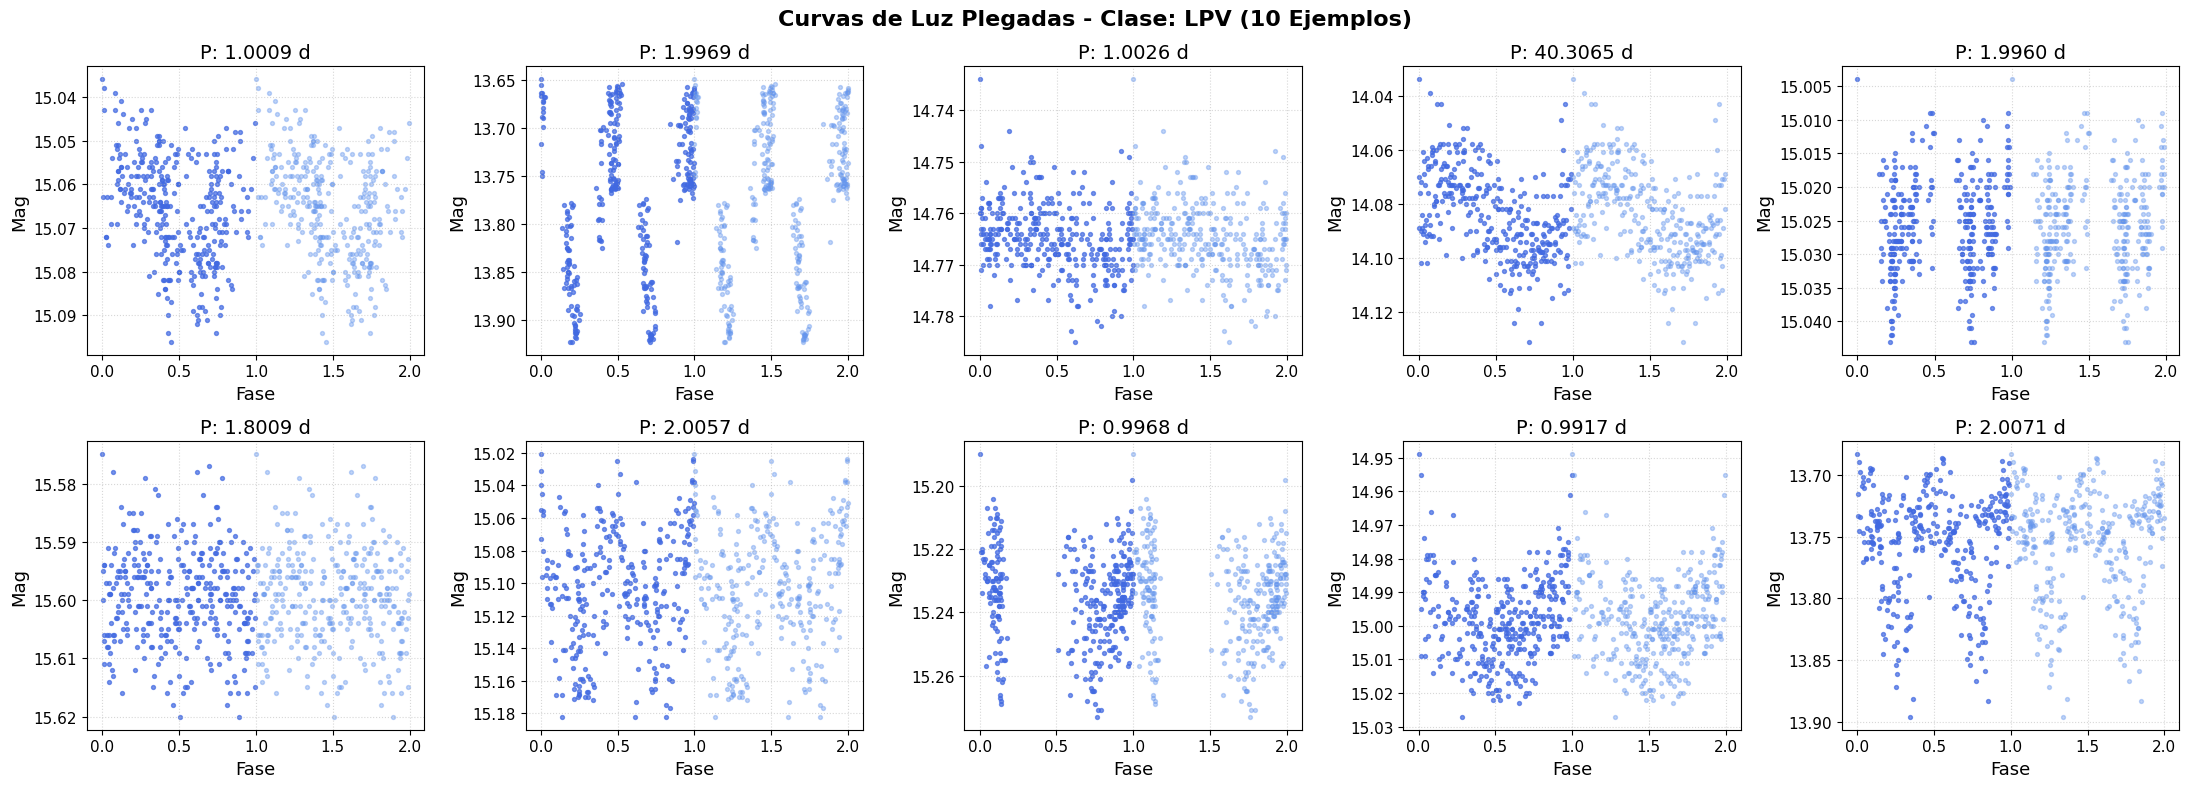

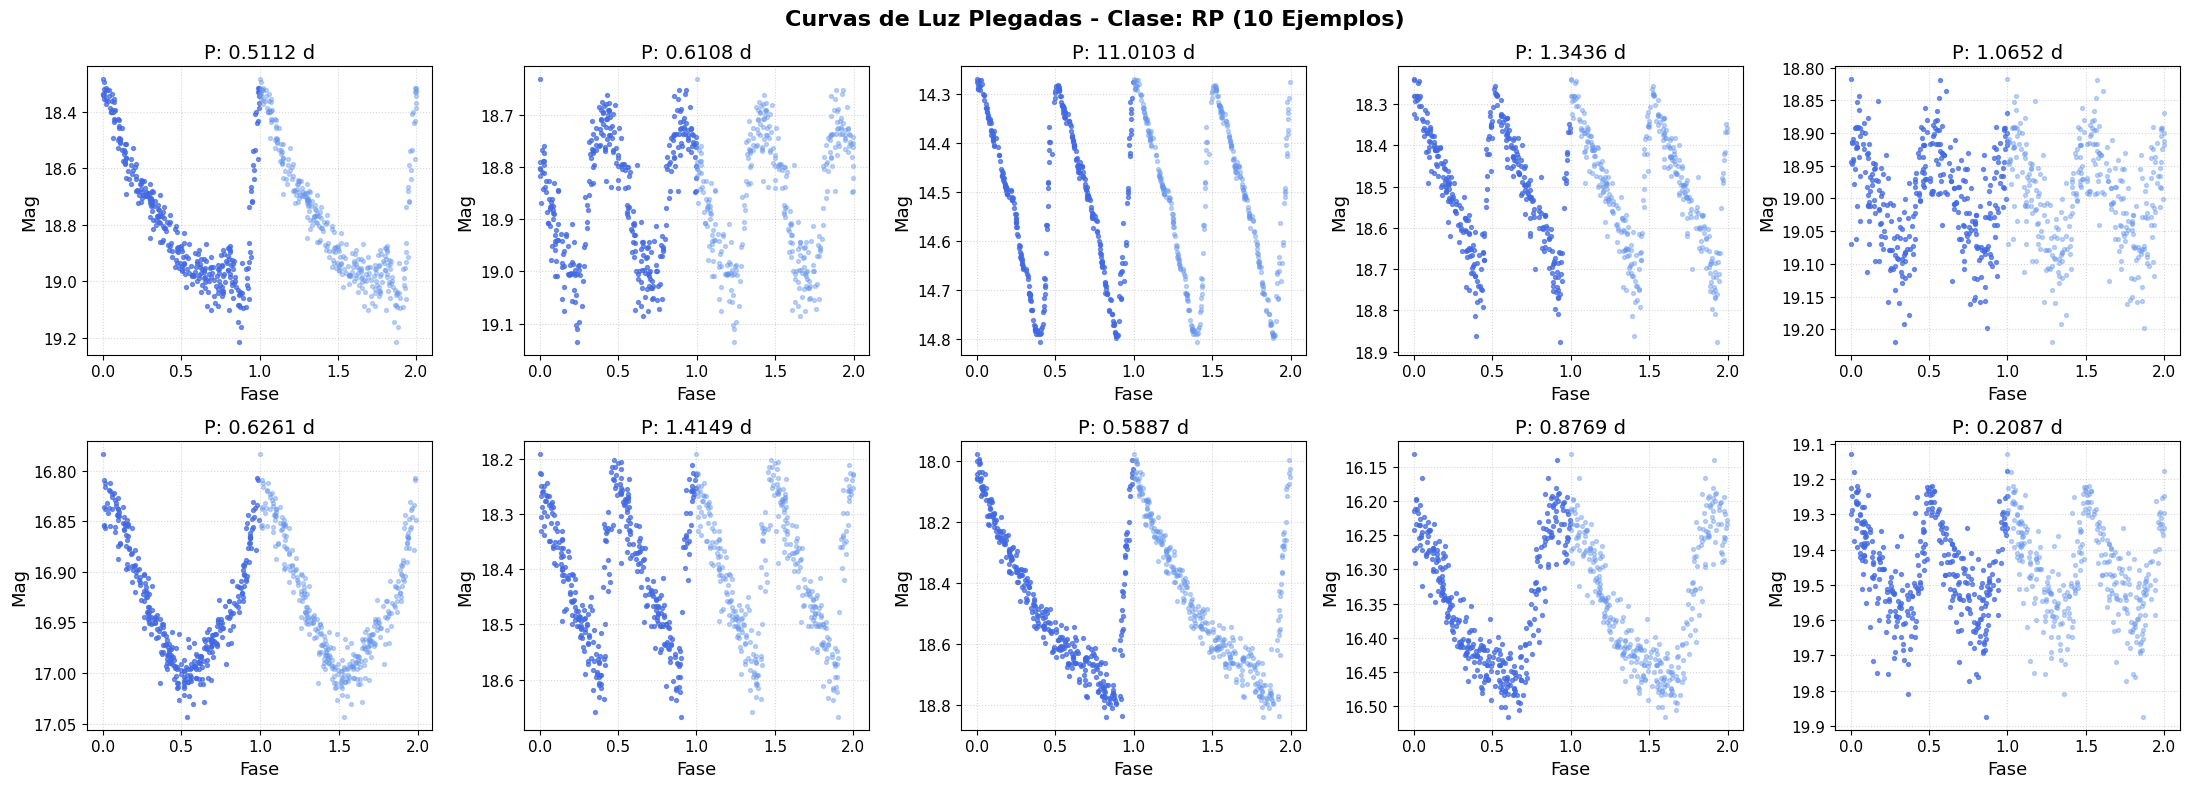

In [38]:
# 1. Identificar las clases únicas presentes (ya sin 'OTHER')
clases_unicas = np.unique(y_valid)

# Configurar el generador aleatorio
rng = np.random.default_rng(seed=42) # Seed opcional por si quieres que siempre salgan las mismas estrellas

# 2. Iterar sobre cada clase de estrella variable
for clase in clases_unicas:
    # Encontrar los índices en X_imputed/y_valid que pertenecen a la clase actual
    indices_de_clase = np.where(y_valid == clase)[0]
    
    # Si la clase tiene menos de 10 estrellas, tomamos las que haya disponibles
    n_muestras = min(10, len(indices_de_clase))
    
    if n_muestras == 0:
        continue
        
    indices_seleccionados = rng.choice(indices_de_clase, size=n_muestras, replace=False)
    
    # 3. Configurar la grilla de gráficos para esta clase (2 filas x 5 columnas)
    fig, axes = plt.subplots(2, 5, figsize=(22, 8))
    axes = axes.flatten()
    
    fig.suptitle(f"Curvas de Luz Plegadas - Clase: {clase} ({n_muestras} Ejemplos)", fontsize=16, fontweight='bold', y=0.98)
    
    for i, idx in enumerate(indices_seleccionados):
        # Recuperar los datos numéricos originales usando el índice mapeado por la máscara
        # Buscamos el índice original en las listas maestras usando la máscara booleana
        idx_original = np.where(mascara_validos)[0][idx]
        
        t = np.array(mjds_list[idx_original])
        mags = np.array(mags_list[idx_original])
        
        # Limpieza rápida de NaNs individuales en la serie temporal
        mask_nan = ~np.isnan(t) & ~np.isnan(mags)
        t, mags = t[mask_nan], mags[mask_nan]
        
        # Extraer el período final calculado que guardamos en X_imputed
        periodo_calculado = X_imputed.loc[idx, 'periodo']
        
        # Encontrar t0 (mínimo como referencia para alinear las fases)
        t0 = t[np.argmin(mags)]
        
        # Calcular la fase (0 a 1)
        fase = ((t - t0) % periodo_calculado) / periodo_calculado
        
        # 4. Graficar la curva de luz duplicando el ciclo para continuidad visual
        ax = axes[i]
        ax.scatter(fase, mags, color='royalblue', s=8, alpha=0.7, label='Ciclo 1')
        ax.scatter(fase + 1, mags, color='cornflowerblue', s=8, alpha=0.4, label='Ciclo 2')
        
        # Formato astronómico: magnitudes invertidas (más brillante arriba)
        ax.invert_yaxis()
        
        # Título sutil para cada subgráfico con el Periodo
        ax.set_title(f"P: {periodo_calculado:.4f} d")
        ax.set_xlabel('Fase')
        ax.set_ylabel('Mag')
        ax.grid(True, linestyle=':', alpha=0.5)
    
    # Ocultar subplots vacíos si la clase tenía menos de 10 estrellas
    for j in range(n_muestras, len(axes)):
        fig.delaxes(axes[j])
        
    plt.tight_layout()
    plt.show()